# Week 1-2: Data Cleaning & Exploratory Data Analysis
## Dataset: Netflix Movies & TV Shows

## Task 1: Dataset Understanding

Loading the dataset and exploring its basic structure.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Charger le dataset
df = pd.read_csv('netflix_titles.csv')

# 2. Afficher les premières lignes
print(df.head())

# 3. Identifier la structure
print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")
print("\nTypes de données :")
print(df.dtypes)

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nVariables numériques : {num_cols}")
print(f"Variables catégorielles : {cat_cols}")

# Clé primaire potentielle
print(f"\nshow_id uniques : {df['show_id'].nunique()} / {df.shape[0]} lignes")

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

**Dataset description:** This dataset contains information about movies and 
TV shows available on Netflix, including title, director, cast, country, 
date added to the platform, release year, content rating, duration, genre 
categories, and description. Each row represents one title. `show_id` is a 
unique identifier and serves as the primary key.

## Task 2: Data Cleaning

### Missing Values

In [2]:
missing = df.isnull().sum()
print(missing[missing > 0])

director      2634
cast           825
country        831
date_added      10
rating           4
duration         3
dtype: int64


**Anomaly found:** Three rows have a duration value (e.g. "74 min") stored 
in the `rating` column instead of the `duration` column, with `duration` 
left empty. This is a data entry/column-shift error, not a normal missing 
value, so it is corrected before handling the remaining missing values.

In [3]:
# Corriger l'anomalie de décalage : la durée s'est retrouvée dans "rating"
shift_mask = df['rating'].isin(['74 min', '84 min', '66 min'])
df.loc[shift_mask, 'duration'] = df.loc[shift_mask, 'rating']
df.loc[shift_mask, 'rating'] = np.nan

print(df.loc[shift_mask, ['title', 'duration', 'rating']])

                                     title duration rating
5541                       Louis C.K. 2017   74 min    NaN
5794                 Louis C.K.: Hilarious   84 min    NaN
5813  Louis C.K.: Live at the Comedy Store   66 min    NaN


**Handling missing values:**
- `director`, `cast`, `country`: filled with "Unknown", since the title 
  itself remains valid and useful for other analyses even without this info.
- `rating`: filled with the most frequent rating (mode), a reasonable 
  default for a categorical field with very few missing values (4 rows).
- `date_added` and `duration`: rows with missing values in these columns 
  are removed, since they are essential for time-based and duration-based 
  analysis, and affect only a very small number of rows.

In [4]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

df = df.dropna(subset=['date_added', 'duration'])
print(f"Nouveau nombre de lignes : {df.shape[0]}")

Nouveau nombre de lignes : 8797


In [5]:
### Duplicate Records

In [6]:
dupes = df.duplicated().sum()
print(f"Doublons trouvés : {dupes}")

df = df.drop_duplicates()
print(f"Nombre de lignes après suppression : {df.shape[0]}")

Doublons trouvés : 0
Nombre de lignes après suppression : 8797


### Standardization
Converting `date_added` to proper datetime format, standardizing text 
formatting, and splitting `duration` into a numeric value and its unit, 
since Movies are measured in minutes while TV Shows are measured in seasons.

In [7]:
# Dates -> vrai format datetime
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], format='%B %d, %Y')

# Texte -> format uniforme (suppression des espaces superflus)
for col in ['type', 'title', 'director', 'cast', 'country', 'rating', 'listed_in']:
    df[col] = df[col].astype(str).str.strip()

# duration contient deux unités différentes (min vs Seasons) -> on sépare
df['duration_value'] = df['duration'].str.extract(r'(\d+)').astype(int)
df['duration_unit'] = np.where(df['type'] == 'Movie', 'min', 'Season(s)')

print(df[['type', 'duration', 'duration_value', 'duration_unit']].head(10))

      type   duration  duration_value duration_unit
0    Movie     90 min              90           min
1  TV Show  2 Seasons               2     Season(s)
2  TV Show   1 Season               1     Season(s)
3  TV Show   1 Season               1     Season(s)
4  TV Show  2 Seasons               2     Season(s)
5  TV Show   1 Season               1     Season(s)
6    Movie     91 min              91           min
7    Movie    125 min             125           min
8  TV Show  9 Seasons               9     Season(s)
9    Movie    104 min             104           min


### Data Validation
Checking `release_year` for unrealistic values (e.g. before 1900 or in 
the future).

In [8]:
invalid_year = ((df['release_year'] < 1900) | (df['release_year'] > 2025)).sum()
print(f"Valeurs de release_year invalides : {invalid_year}")

Valeurs de release_year invalides : 0


### Cleaning Summary

In [10]:
summary = pd.DataFrame({
    'Issue Found': [
        'Misaligned values (duration in rating column)',
        'Missing Values (director, cast, country)',
        'Missing Values (rating)',
        'Missing Values (date_added, duration)',
        'Duplicates',
        'Standardization'
    ],
    'Action Taken': [
        'Corrected: values moved back to duration column',
        'Filled with "Unknown"',
        'Filled with the most frequent rating (mode)',
        'Rows removed (small number affected)',
        'Removed (0 found)',
        'Dates converted, text trimmed, duration split into value + unit'
    ]
})
print(summary)

                                     Issue Found  \
0  Misaligned values (duration in rating column)   
1       Missing Values (director, cast, country)   
2                        Missing Values (rating)   
3          Missing Values (date_added, duration)   
4                                     Duplicates   
5                                Standardization   

                                        Action Taken  
0    Corrected: values moved back to duration column  
1                              Filled with "Unknown"  
2        Filled with the most frequent rating (mode)  
3               Rows removed (small number affected)  
4                                  Removed (0 found)  
5  Dates converted, text trimmed, duration split ...  


### Export Cleaned Dataset

In [11]:
df.to_csv('netflix_cleaned.csv', index=False)
print(f"Dataset final propre : {df.shape[0]} lignes, {df.shape[1]} colonnes")

Dataset final propre : 8797 lignes, 14 colonnes


## Task 3: Exploratory Data Analysis (EDA)

Now that the dataset is cleaned, we generate summary statistics and explore 
key patterns in the data.

### Summary Statistics
Descriptive statistics for the numerical columns: `release_year` and 
`duration_value`.

In [12]:
# S'assurer que date_added est bien en datetime (au cas où le CSV a été relu)
df['date_added'] = pd.to_datetime(df['date_added'])

summary_stats = df[['release_year', 'duration_value']].describe()
print(summary_stats)

       release_year  duration_value
count   8797.000000     8797.000000
mean    2014.183472       69.921792
std        8.822191       50.788599
min     1925.000000        1.000000
25%     2013.000000        2.000000
50%     2017.000000       88.000000
75%     2019.000000      106.000000
max     2021.000000      312.000000


### Analysis 1: Movies vs TV Shows Distribution

In [13]:
type_counts = df['type'].value_counts()
print(type_counts)

type
Movie      6131
TV Show    2666
Name: count, dtype: int64


### Analysis 2: Content Added by Year

In [14]:
df['year_added'] = df['date_added'].dt.year
content_by_year = df['year_added'].value_counts().sort_index()
print(content_by_year)

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64


### Analysis 3: Top Content-Producing Countries

In [15]:
# La colonne country contient parfois plusieurs pays séparés par une virgule
# -> on éclate chaque ligne en plusieurs pour compter correctement
countries_split = df['country'].str.split(', ')
all_countries = countries_split.explode()
top_countries = all_countries[all_countries != 'Unknown'].value_counts().head(10)
print(top_countries)

country
United States     3683
India             1046
United Kingdom     803
Canada             445
France             393
Japan              317
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


### Analysis 4: Most Common Ratings

In [16]:
rating_counts = df['rating'].value_counts().head(10)
print(rating_counts)

rating
TV-MA    3212
TV-14    2157
TV-PG     861
R         799
PG-13     490
TV-Y7     333
TV-Y      306
PG        287
TV-G      220
NR         79
Name: count, dtype: int64


### Analysis 5: Most Common Genres/Categories

In [17]:
# listed_in contient aussi plusieurs genres séparés par une virgule
genres_split = df['listed_in'].str.split(', ')
all_genres = genres_split.explode()
top_genres = all_genres.value_counts().head(10)
print(top_genres)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


## Task 4: Data Visualization

At least 5 visualizations, each with a title, axis labels, and a short 
explanation of the finding.

### Visualization 1: Movies vs TV Shows (Pie Chart)

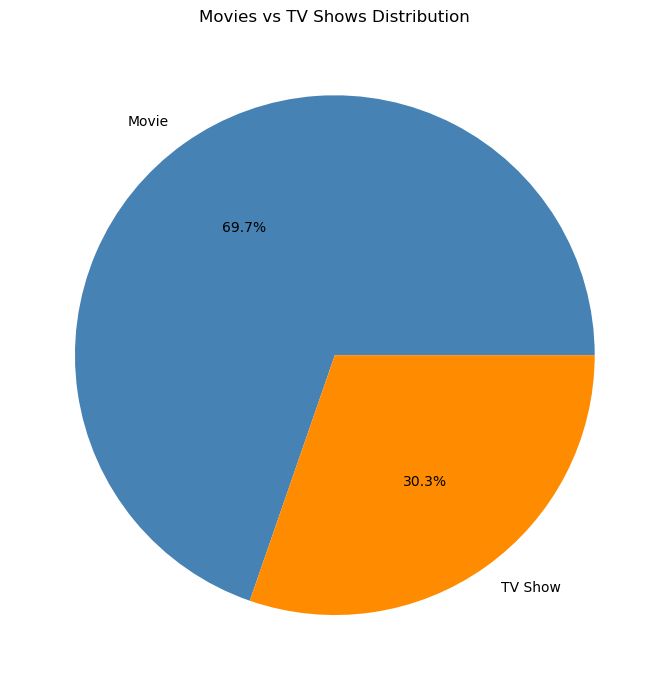

In [18]:
plt.figure(figsize=(7,7))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
        colors=['steelblue', 'darkorange'])
plt.title('Movies vs TV Shows Distribution')
plt.tight_layout()
plt.show()

**Finding:** Movies represent the large majority of Netflix's catalog 
(around 70%), with TV Shows making up the remaining share.

### Visualization 2: Content Added Per Year (Line Chart)

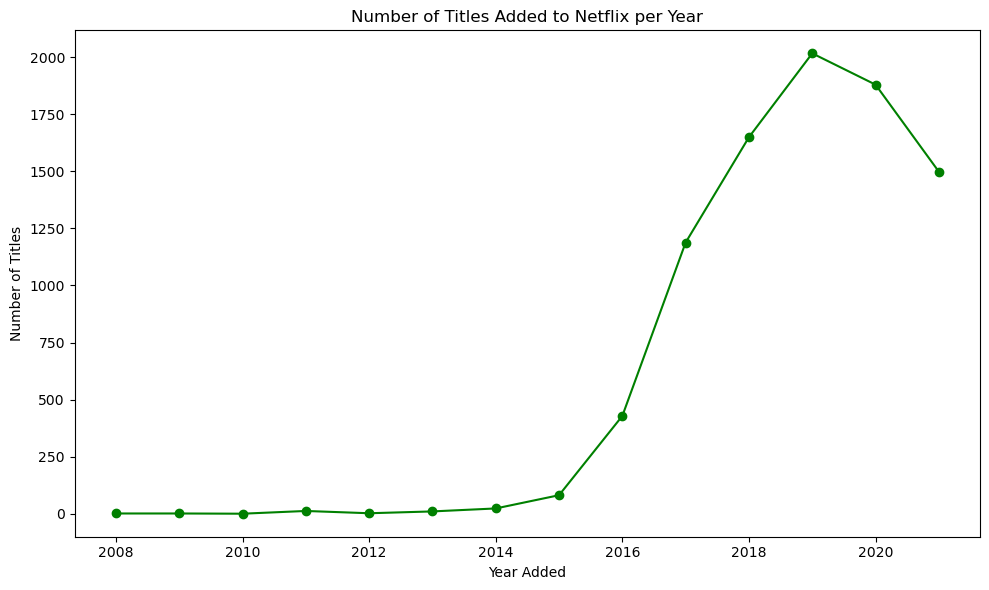

In [19]:
plt.figure(figsize=(10,6))
content_by_year.plot(kind='line', marker='o', color='green')
plt.title('Number of Titles Added to Netflix per Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()

**Finding:** Netflix's catalog grew rapidly between 2016 and 2019, peaking 

in 2019, followed by a slight decline in 2020-2021 — possibly linked to 

production slowdowns during the COVID-19 pandemic. 

### Visualization 3: Top 10 Content-Producing Countries (Bar Chart)

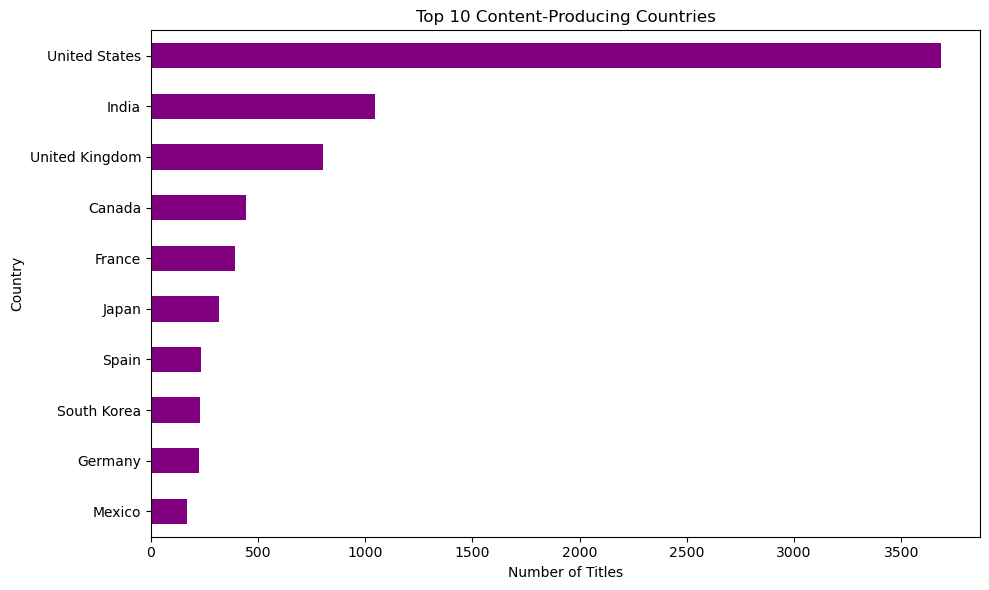

In [20]:
plt.figure(figsize=(10,6))
top_countries.plot(kind='barh', color='purple')
plt.title('Top 10 Content-Producing Countries')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Finding:** The United States dominates content production by a wide margin, 
followed by India and the United Kingdom.

### Visualization 4: Most Common Content Ratings (Bar Chart)

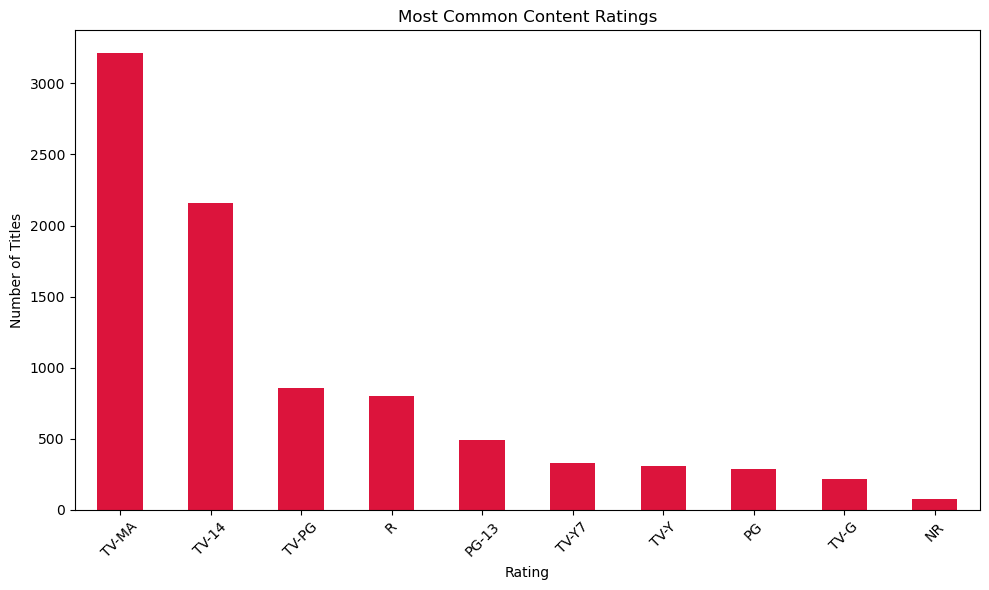

In [21]:
plt.figure(figsize=(10,6))
rating_counts.plot(kind='bar', color='crimson')
plt.title('Most Common Content Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Finding:** TV-MA (mature audiences) and TV-14 are by far the most common 

ratings, suggesting Netflix's catalog leans toward content for older 

teenagers and adults rather than young children.  

### Visualization 5: Top 10 Genres/Categories (Bar Chart)

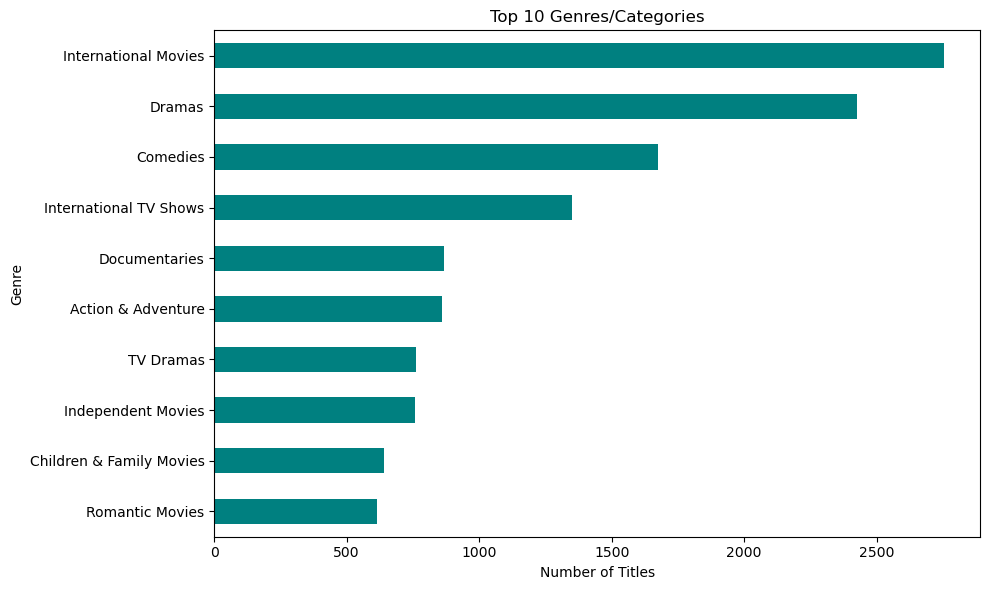

In [22]:
plt.figure(figsize=(10,6))
top_genres.plot(kind='barh', color='teal')
plt.title('Top 10 Genres/Categories')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Task 5: Key Insights

- **Insight 1 — Content type mix:** Movies make up roughly 70% of the 
  Netflix catalog, with TV Shows at about 30% (see Visualization 1). This 
  suggests Netflix's library is still primarily movie-driven, though TV 
  content plays a meaningful role.

- **Insight 2 — Catalog growth and slowdown:** The number of titles added 
  grew sharply from 2016 to 2019, then declined in 2020-2021 
  (see Visualization 2), which aligns with widely reported production 
  disruptions during the COVID-19 pandemic.

- **Insight 3 — US-centric content:** The United States is the single 
  largest content-producing country by a wide margin, followed by India 
  and the UK (see Visualization 3), reflecting Netflix's historical roots 
  and continued strength in the US market.

- **Insight 4 — Mature-audience skew:** TV-MA and TV-14 are the two most 
  common ratings (see Visualization 4), indicating that Netflix's catalog 
  is weighted toward teenage and adult audiences rather than young children.

- **Insight 5 — Genre diversity with a global focus:** International Movies 
  and Dramas are the leading genres (see Visualization 5), supporting 
  Netflix's strategy of curating a globally diverse content library rather 
  than focusing narrowly on a single genre or region.